# Step 120 后的快速实验策略

## tl;dr

- 不直接做96K正式训练。4道未收尾题全部在同一26回合边界停止，且都留下一个未返回工具调用；问题首先是回合控制和重复探索，不是单纯上下文不足。
- 96K训练侧大概率能装下，但当前24序列/副本的rollout并发不能原样保留。先用48K强制收尾，再测64K；96K只做剩余失败题的定向推理。
- 任何更长训练前先跑5步可学习性金丝雀。按Step 120实测，100步加最终验证约18.1小时，5步加完整val20约2小时。

## Context & Methods

本 notebook 用于决定下一次GPU实验顺序，而不是宣称某个策略已经带来质量提升。

### Key Assumptions

- 训练显存沿用既有48K full-recompute、micro-batch 1、TP4/PP2/CP2和CPU optimizer/gradient offload模型。
- rollout缓存按16个全注意力层与48个GDN层估算；正式运行的HBM实测用于校准最坏增量。
- GPU小时不含冷启动和模型加载；真正执行前仍需容量探针。

In [1]:
from pathlib import Path
import json
import warnings
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="Glyph .* missing from font")
plt.style.use("seaborn-v0_8-whitegrid")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
source = ROOT / "docs" / "next_experiment_strategy_20260810_summary.json"
summary = json.loads(source.read_text(encoding="utf-8"))
summary["decision"]

'Do not start a formal 96K training run; test finalization control first, then 64K, and reserve 96K for targeted inference-only diagnosis.'

## Data

来源包括Step 120固定val20、老板原版评分聚合、完整driver耗时、48K容量实测和服务器模型配置。仓库只保留聚合结果；原始轨迹和机器路径不进入本 notebook。

In [2]:
audit = summary["completion_audit"]
pd.DataFrame([
    {"group": "Incomplete", **audit["incomplete"]},
    {"group": "Complete", **audit["complete"]},
]).set_index("group").round(3)

,tasks,assistant_turns_mean,sql_calls_mean,commands_mean,duplicate_commands_mean,redundancy_oscillation_rate,output_chars_mean
group,,,,,,,
Incomplete,4,26.0,24.500,38.25,30.750,1.000,64223.250
Complete,16,15.0,8.562,25.00,19.125,0.812,46304.875


## Results

### 1. 未收尾是统一的回合边界问题

4道未收尾题全部走到26回合，平均执行24.5条SQL、30.75条重复命令，振荡率100%。已收尾题平均15回合和19.13条重复命令。增加上下文但不改变回合与收尾控制，不会越过这个停止边界。

In [3]:
incomplete = pd.DataFrame(audit["incomplete_details"])
incomplete[["task_id", "assistant_turns", "tool_calls", "tool_responses", "duplicate_commands", "redundancy_oscillation"]]

,task_id,assistant_turns,tool_calls,tool_responses,duplicate_commands,redundancy_oscillation
0,task_000070,26,50,49,38,True
1,task_000133,26,26,25,18,True
2,task_000080,26,46,45,36,True
3,task_000196,26,42,41,31,True


### 2. 96K训练侧可行，rollout并发必须下降

模型原生最大位置为262,144，96K不需要RoPE外推。训练规划峰值从48K的43.9 GiB增至96K的48.6 GiB，仍有12.6 GiB规划余量。rollout最坏缓存则随活跃长序列数增长：48K→96K每条约增加0.75 GiB；24条跑满会增加18 GiB，超过当前约11 GiB同步后余量。

In [4]:
capacity = pd.DataFrame(summary["capacity"]["scenario_rows"])
training = capacity.drop_duplicates("context_k")[["context_k", "training_planning_peak_gib", "training_headroom_gib"]].set_index("context_k")
training

,training_planning_peak_gib,training_headroom_gib
context_k,,
48,43.914098,17.355902
64,45.486363,15.783637
80,47.058629,14.211371
96,48.630894,12.639106


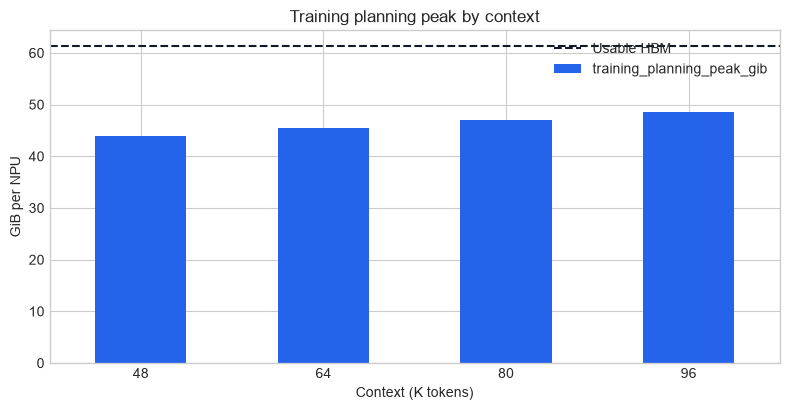

In [5]:
ax = training["training_planning_peak_gib"].plot(kind="bar", figsize=(8, 4.2), color="#2563EB", rot=0)
ax.axhline(summary["capacity"]["usable_hbm_gib"], color="#111827", linestyle="--", label="Usable HBM")
ax.set_title("Training planning peak by context")
ax.set_xlabel("Context (K tokens)")
ax.set_ylabel("GiB per NPU")
ax.legend()
plt.tight_layout()
plt.show()

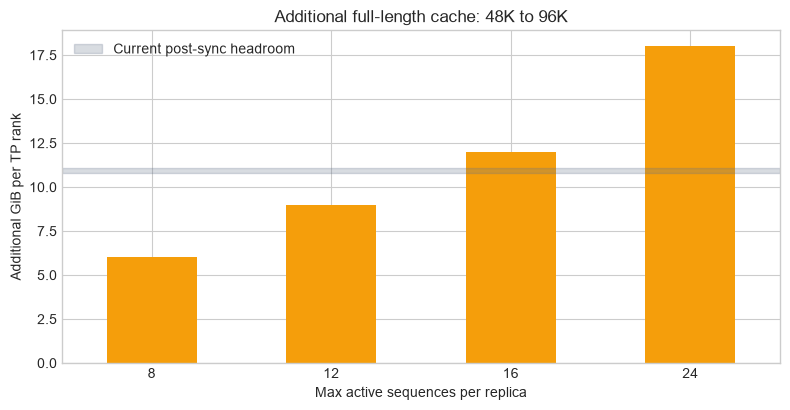

In [6]:
increment = pd.Series(summary["capacity"]["calibrated_increment_by_concurrency_gib"], dtype=float)
ax = increment.plot(kind="bar", figsize=(8, 4.2), color="#F59E0B", rot=0)
ax.axhspan(10.8, 11.1, color="#64748B", alpha=0.25, label="Current post-sync headroom")
ax.set_title("Additional full-length cache: 48K to 96K")
ax.set_xlabel("Max active sequences per replica")
ax.set_ylabel("Additional GiB per TP rank")
ax.legend()
plt.tight_layout()
plt.show()

### 3. 先做不训练或5步实验

100步按本轮实测约17.0小时更新，加完整val20和保存约18.1小时。5步即使保留完整val20也约2小时，因此应把“能否学到”变成前置门禁。

In [7]:
cost = pd.DataFrame(summary["runtime_and_experiments"]["training_cost_projection"])
cost.round(2)

,steps,update_hours,with_full_val_and_save_hours
0,5,0.85,2.00
1,10,1.70,2.85
2,20,3.40,4.55
3,100,16.99,18.14


In [8]:
experiments = pd.DataFrame(summary["runtime_and_experiments"]["ranked_experiments"])
experiments[["priority", "experiment", "training_steps", "new_trajectories", "estimated_gpu_hours_excluding_cold_start", "decision_gate"]]

,priority,experiment,training_steps,new_trajectories,estimated_gpu_hours_excluding_cold_start,decision_gate
0,1,48K 强制收尾哨兵集,0,6,0.4–0.8,4道既有未收尾题至少救回2道，且2道已答对/高分题不退化
1,2,64K + 32轮哨兵集,0,6,0.6–1.2,相对48K强制收尾额外救回至少1道，且单位题耗时增幅不超过60%
2,3,96K 定向诊断,0,4,0.8–1.8,至少救回64K仍失败任务的一半；否则不把96K带入训练
3,4,离线奖励与反循环回放,0,0,0,提高mixed-signal比例，同时保持正确响应相对错误响应的排序一致性
4,5,5步可学习性金丝雀,5,40,1.0–2.0,训练prompt上dense正确性明显提高，独立哨兵不退化；否则停止扩步
5,6,离线纠错SFT/DPO原型,0,0,无rollout，主要是训练侧,先证明能提高收尾与正确性，再决定是否替代昂贵的在线GRPO探索


## Takeaways

1. 第一优先级是48K强制收尾哨兵集：第22轮或剩余4K token时停止工具调用，直接作答。
2. 只有它救不回至少2/4失败题，才进入64K+32轮；64K比96K更可能保留现有吞吐。
3. 96K只对64K仍失败的题做定向推理，且先以8序列/副本完成容量探针。
4. 同时做零GPU离线回放：完成硬门控、无新证据/重复命令惩罚、dense权重30/50/70%。
5. 最终候选必须通过5步、2 groups/update的可学习性金丝雀；训练prompt学不会时禁止扩到20或100步。

### Robustness limits

- rollout缓存是规划与最坏增量，不是96K满并发实测。
- 6题哨兵用于快速淘汰，不足以证明泛化；通过后仍需密封集确认。
- 96K可能让模型多探索而非更正确，因此完成率、数值正确性和单位题耗时必须同时门禁。